In [84]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Stroke Prediction Dataset

### Variables
1. **id**: unique identifier
2. **gender**: "Male", "Female" or "Other"
3. **age**: age of the patient
4. **hypertension**: `0` if the patient doesn't have hypertension, `1` if the patient has hypertension
5. **heart_disease**: `0` if the patient doesn't have any heart diseases, `1` if the patient has a heart disease
6. **ever_married**: "No" or "Yes"
7. **work_type**: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8. **Residence_type**: "Rural" or "Urban"
9. **avg_glucose_level**: average glucose level in blood
10. **bmi**: body mass index
11. **smoking_status**: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12. **stroke**: `1` if the patient had a stroke or `0` if not

In [64]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(os.path.join(path, "healthcare-dataset-stroke-data.csv"))
print(df.shape)
df.head(10)

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [109]:
#Making sure NaN values are being treated as missing values or string.
#There is also "unknown" on smoking_status, which could count as missing values, but won't be explored here.
print((df['bmi'] == 'NaN').sum())
df.isnull().sum()

0


id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [110]:
#Let's handle missing values in the 'bmi' column using KNN imputation
imputer = KNNImputer()
df[['bmi']] = imputer.fit_transform(df[['bmi']]).round(2)

In [119]:
"""
variables = [variable for variable in df.columns if variable not in ['id', 'stroke']]
var_cat = []
var_num = []
#I will define some variables that are numerical as categorical since they are discrete and have a limited number of unique values, for example hypertension.
for col in variables:
    if df[col].nunique() == 2:
        var_cat.append(col)
    else:
        var_num.append(col)
        
df_cat = df[var_cat]
df_num = df[var_num]
df_num.head()
"""

"\nvariables = [variable for variable in df.columns if variable not in ['id', 'stroke']]\nvar_cat = []\nvar_num = []\n#I will define some variables that are numerical as categorical since they are discrete and have a limited number of unique values, for example hypertension.\nfor col in variables:\n    if df[col].nunique() == 2:\n        var_cat.append(col)\n    else:\n        var_num.append(col)\n\ndf_cat = df[var_cat]\ndf_num = df[var_num]\ndf_num.head()\n"

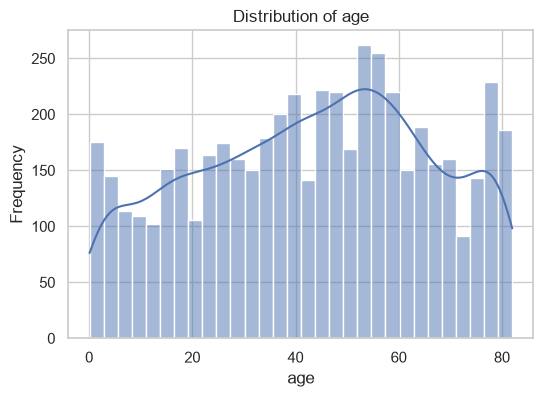

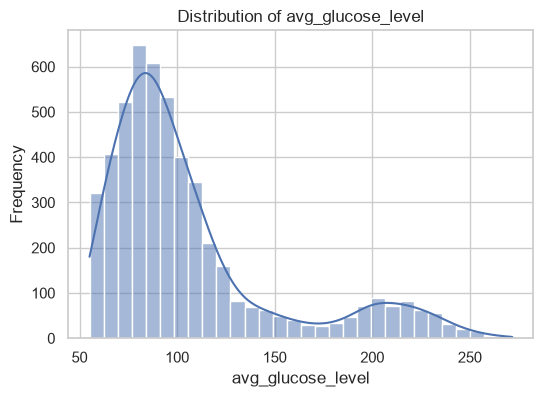

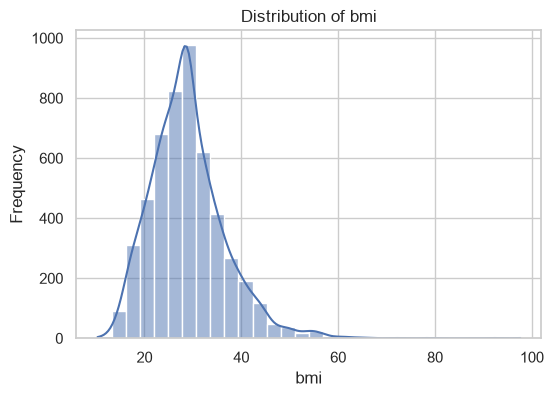

In [142]:
#Now to check the distribution of the variables.

var_set1 = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
var_set2 = ['hypertension', 'heart_disease']
var_cont = ['age', 'avg_glucose_level', 'bmi']

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

for col in var_cont:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

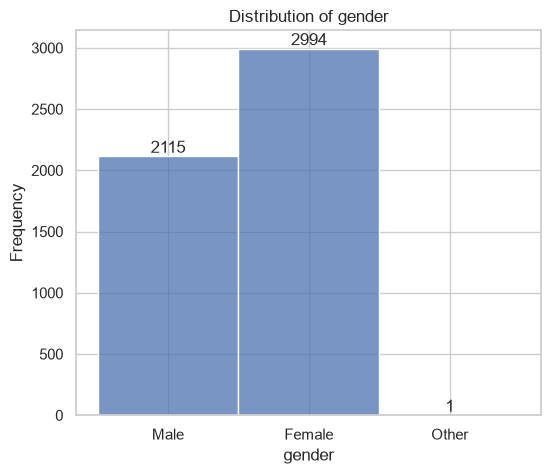

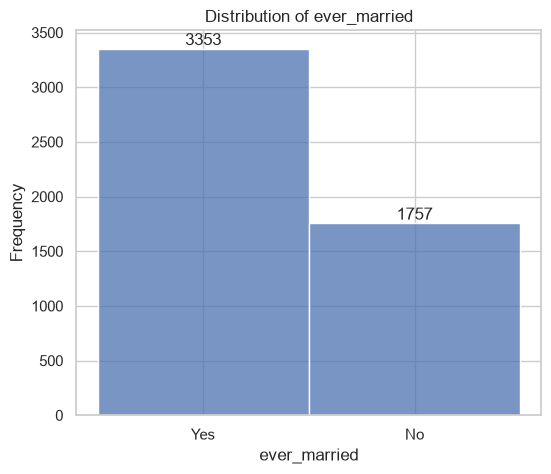

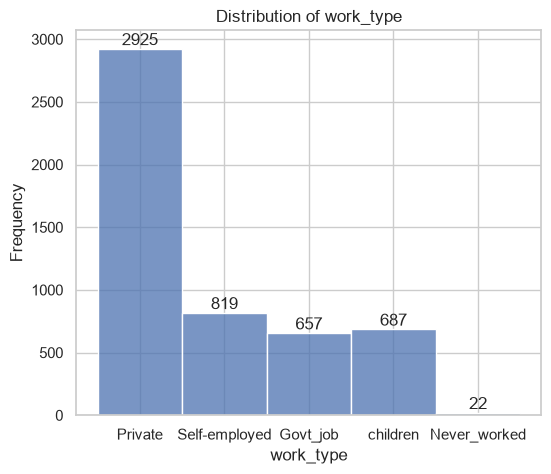

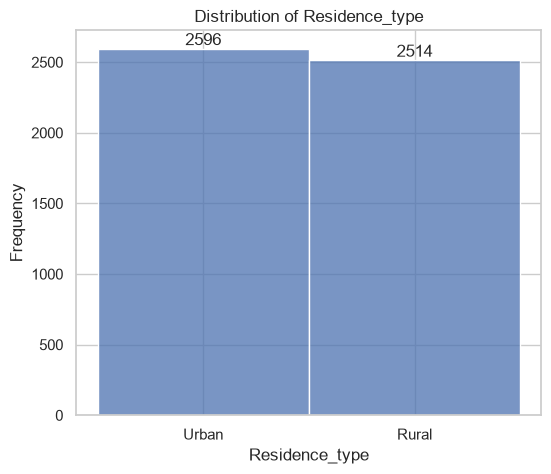

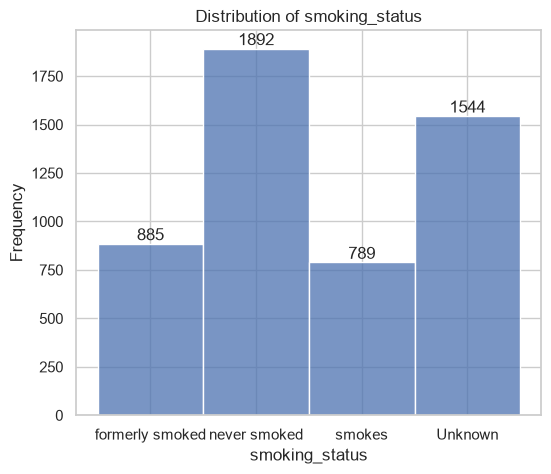

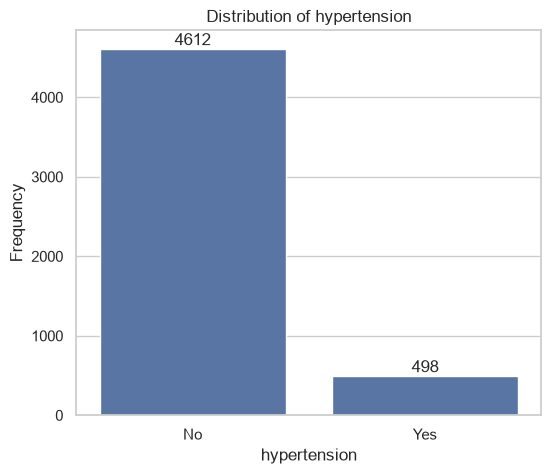

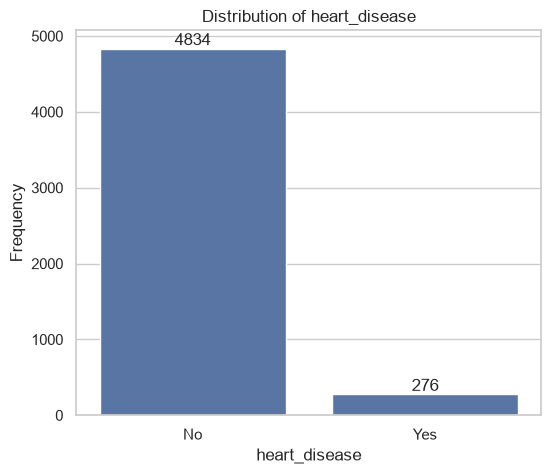

In [172]:
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

for col in var_set1:
    plt.figure(figsize=(6, 5))
    ax = sns.histplot(data=df, x=col, bins=30)
    ax.bar_label(ax.containers[0])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

for col in var_set2:
    plt.figure(figsize=(6, 5))
    ax = sns.countplot(data=df, x=col)
    ax.bar_label(ax.containers[0])
    plt.title(f"Distribution of {col}")
    plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
    plt.ylabel("Frequency")
    plt.show()

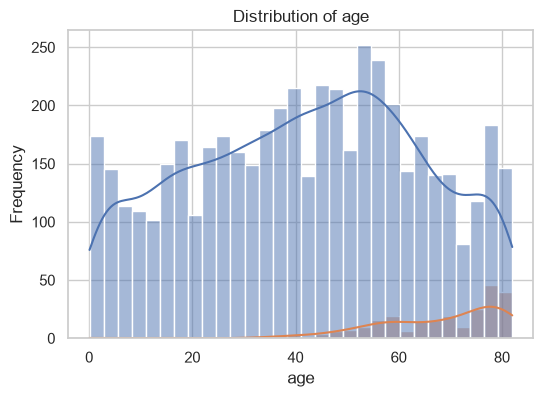

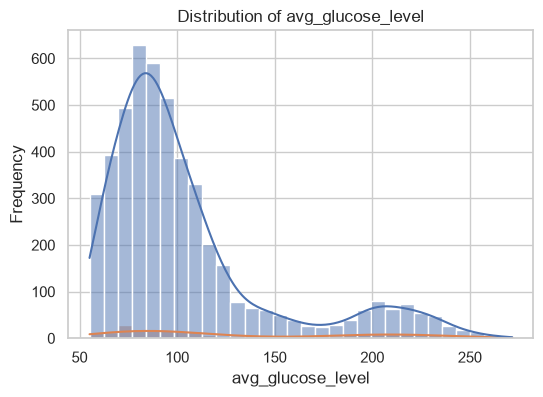

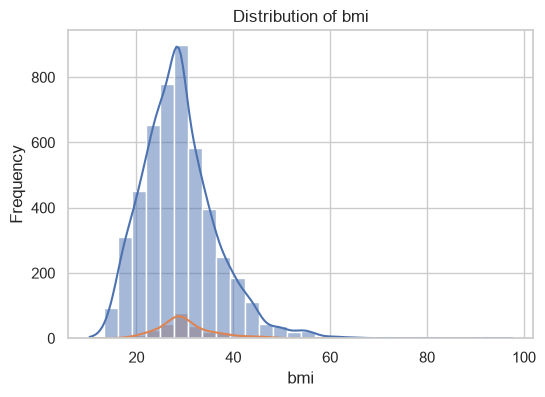

In [171]:
#Let's overlay the stroke variable on top of other variables to conclude if there looks to be a correlation

for col in var_cont:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=30, hue=df['stroke'], kde=True, legend=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

As we can see there seems to be a correlation between old age and the amount of strokes. BMI and stroke peaking at the same point might just be due to it being the average bmi.

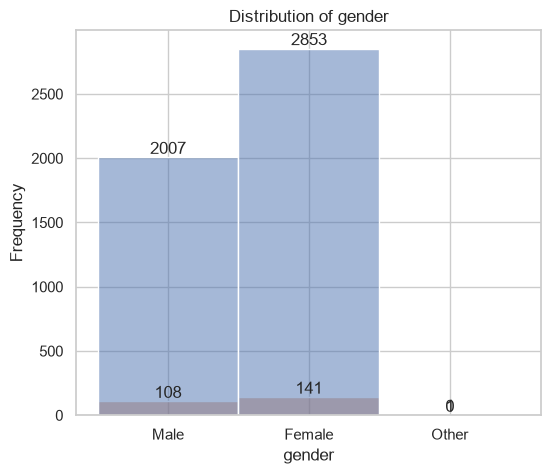

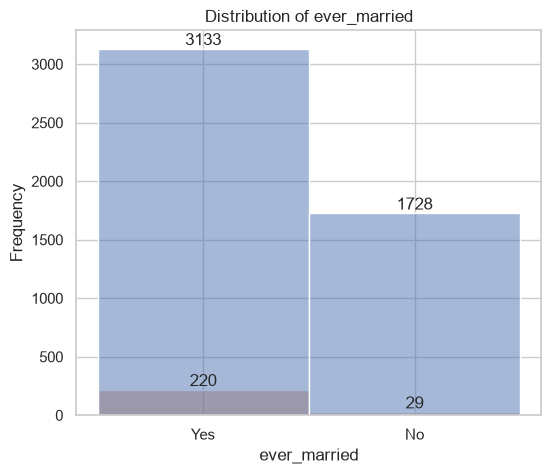

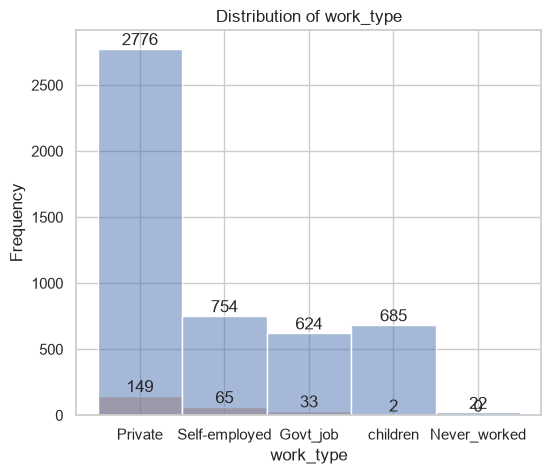

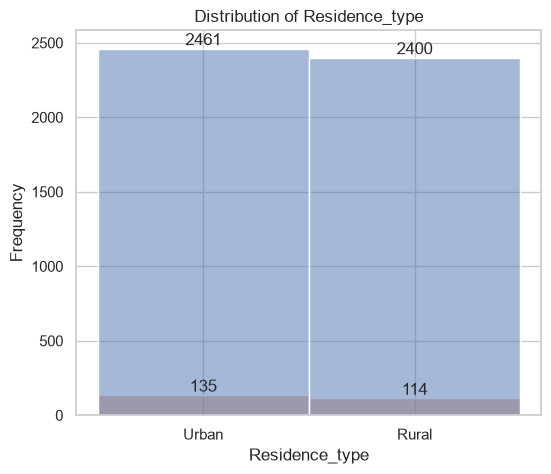

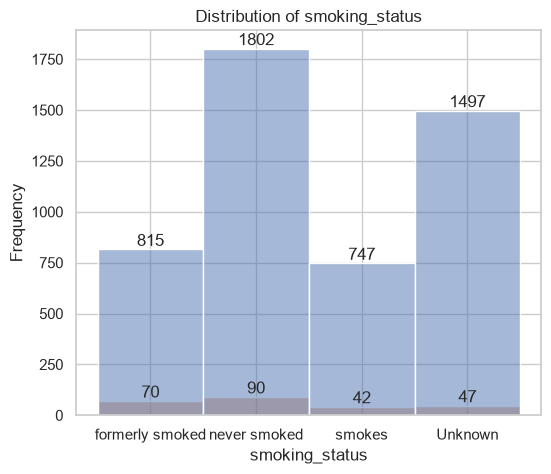

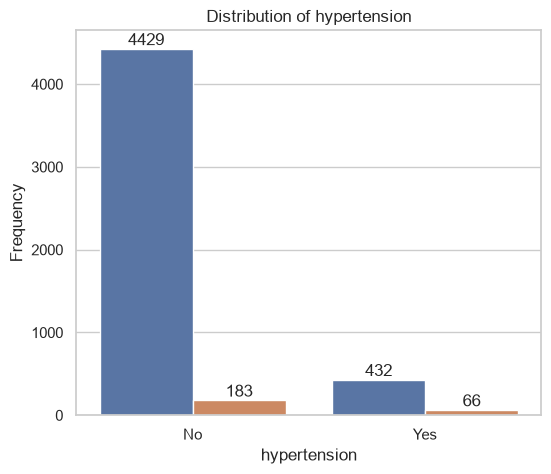

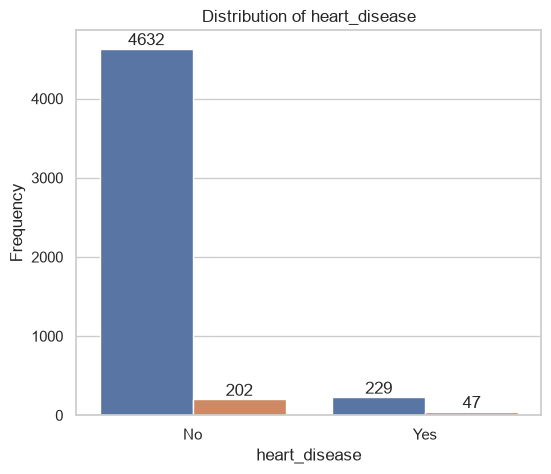

In [ ]:
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

for col in var_set1:
    plt.figure(figsize=(6, 5))
    ax = sns.histplot(data=df, x=col, hue=df['stroke'], legend=False)
    ax.bar_label(ax.containers[0])
    ax.bar_label(ax.containers[1])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#Can't use histplots for var_set2 since they are in '0' and '1',
#would need to change all 0's to no and 1's to yes. Easy fix but will leave it this way for variation

for col in var_set2:
    plt.figure(figsize=(6, 5))
    ax = sns.countplot(data=df, x=col, hue=df['stroke'], legend=False)
    ax.bar_label(ax.containers[0])
    ax.bar_label(ax.containers[1])
    plt.title(f"Distribution of {col}")
    plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
    plt.ylabel("Frequency")
    plt.show()

<Axes: >

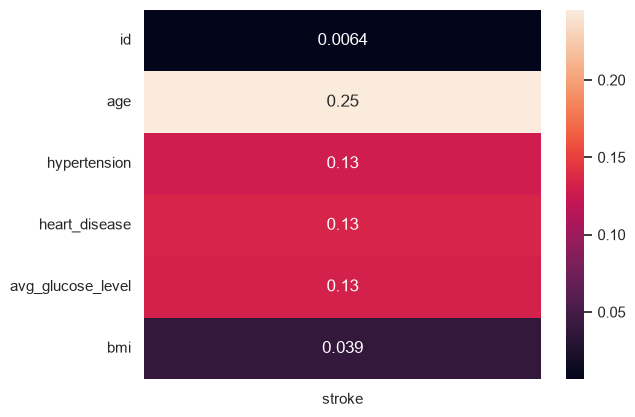

In [199]:
#Now to check what the correlation heatmap looks like
corr = df.corr(numeric_only=True)[['stroke']].drop(index='stroke')
sns.heatmap(corr, annot=True)

# TO DO: Okay we need to make categorical values into numerical for them to work here. maybe check out onehotcoding and if that makes sense here?
#also remove ID from there.